 currently incomplete

In [58]:
import pandas as pd


# https://www.kaggle.com/datasets/resulcaliskan/diamonds
data = pd.read_csv("diamonds.csv")

data

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,5.75,5.76,3.50,2757
53936,0.72,Good,D,SI1,63.1,55.0,5.69,5.75,3.61,2757
53937,0.70,Very Good,D,SI1,62.8,60.0,5.66,5.68,3.56,2757
53938,0.86,Premium,H,SI2,61.0,58.0,6.15,6.12,3.74,2757


In [59]:
data.describe()

,carat,depth,table,x,y,z,price
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,5.731157,5.734526,3.538734,3932.799722
std,0.474011,1.432621,2.234491,1.121761,1.142135,0.705699,3989.439738
min,0.200000,43.000000,43.000000,0.000000,0.000000,0.000000,326.000000
25%,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000,950.000000
50%,0.700000,61.800000,57.000000,5.700000,5.710000,3.530000,2401.000000
75%,1.040000,62.500000,59.000000,6.540000,6.540000,4.040000,5324.250000
max,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000,18823.000000


x y and z having missing values where they equal 0. should check them out

In [60]:
data.query("x == 0 or y == 0 or z == 0")

,carat,cut,color,clarity,depth,table,x,y,z,price
2207,1.00,Premium,G,SI2,59.1,59.0,6.55,6.48,0.0,3142
2314,1.01,Premium,H,I1,58.1,59.0,6.66,6.60,0.0,3167
4791,1.10,Premium,G,SI2,63.0,59.0,6.50,6.47,0.0,3696
5471,1.01,Premium,F,SI2,59.2,58.0,6.50,6.47,0.0,3837
10167,1.50,Good,G,I1,64.0,61.0,7.15,7.04,0.0,4731
11182,1.07,Ideal,F,SI2,61.6,56.0,0.00,6.62,0.0,4954
11963,1.00,Very Good,H,VS2,63.3,53.0,0.00,0.00,0.0,5139
13601,1.15,Ideal,G,VS2,59.2,56.0,6.88,6.83,0.0,5564
15951,1.14,Fair,G,VS1,57.5,67.0,0.00,0.00,0.0,6381
24394,2.18,Premium,H,SI2,59.4,61.0,8.49,8.45,0.0,12631


In [ ]:
len(data.query("x == 0 or y == 0 or z == 0"))


20

Only 20 out of 53940 rows. dropping them shouldn't hurt

In [ ]:
# combine x (width), y (length) and z (height) into just volume
# Price relates more linearly to overall size than to each dimension separately
# Reduces multicollinearity between x, y, z
data['volume'] = data.x * data.y * data.z
data = data.drop(columns=['x', 'y', 'z'])
data = data[data['volume'] > 0]

In [49]:
# check for null values
data[data.isnull().any(axis=1)]

,carat,cut,color,clarity,depth,table,price,volume


In [50]:
data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   volume   53940 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 10.2 MB


In [51]:
data[['cut', 'color','clarity']] = data[['cut', 'color','clarity']].astype('category')
data.info(memory_usage='deep') 
# can shrink down data usage. not much here anyways but still good practice for efficiency

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   volume   53940 non-null  float64 
dtypes: category(3), float64(4), int64(1)
memory usage: 2.2 MB


In [52]:
# check for ordinal/one hot encoding
data.cut.value_counts(), data.color.value_counts(), data.clarity.value_counts()

(cut
 Ideal        21551
 Premium      13791
 Very Good    12082
 Good          4906
 Fair          1610
 Name: count, dtype: int64,
 color
 G    11292
 E     9797
 F     9542
 H     8304
 D     6775
 I     5422
 J     2808
 Name: count, dtype: int64,
 clarity
 SI1     13065
 VS2     12258
 SI2      9194
 VS1      8171
 VVS2     5066
 VVS1     3655
 IF       1790
 I1        741
 Name: count, dtype: int64)

In [53]:
data.describe()

,carat,depth,table,price,volume
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,129.849403
std,0.474011,1.432621,2.234491,3989.439738,78.245262
min,0.200000,43.000000,43.000000,326.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,65.136830
50%,0.700000,61.800000,57.000000,2401.000000,114.808572
75%,1.040000,62.500000,59.000000,5324.250000,170.842451
max,5.010000,79.000000,95.000000,18823.000000,3840.598060


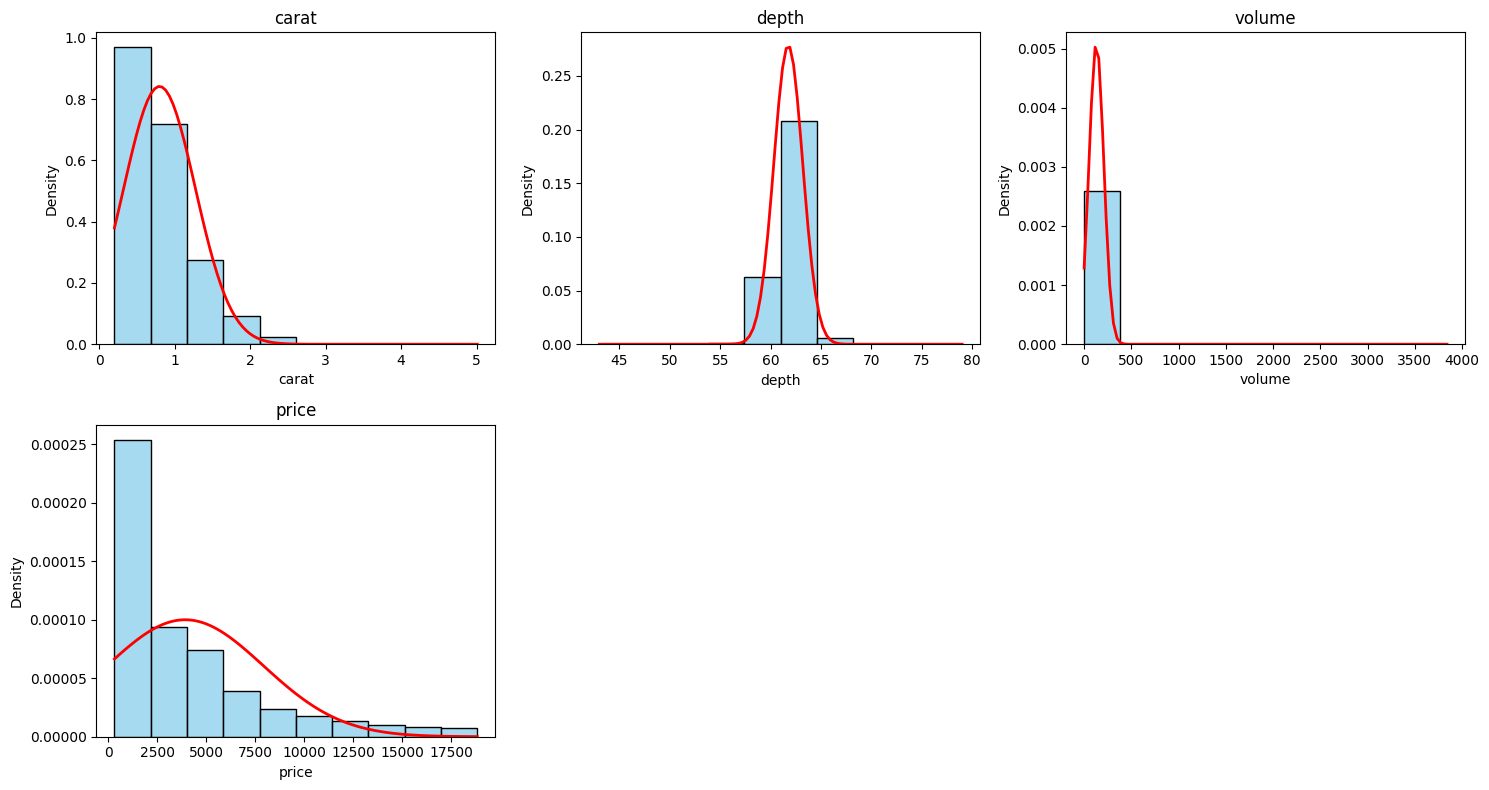

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

cols = ["carat", "depth", "volume", "price"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data[col], bins=10, stat="density", ax=axes[i], color='skyblue', kde=False)
    
    # overlay normal distribution
    mu, sigma = data[col].mean(), data[col].std()
    x = np.linspace(data[col].min(), data[col].max(), 100)
    axes[i].plot(x, norm.pdf(x, mu, sigma), 'r', lw=2)
    
    axes[i].set_title(col)

# remove unused subplots
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [55]:
data[['carat', 'depth', 'volume', 'price']].corr()

,carat,depth,volume,price
carat,1.000000,0.028224,0.976308,0.921591
depth,0.028224,1.000000,0.009157,-0.010647
volume,0.976308,0.009157,1.000000,0.902385
price,0.921591,-0.010647,0.902385,1.000000
